In [12]:
import os
import pandas as pd
import numpy as np
import librosa

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

layers = tf.keras.layers
models = tf.keras.models
to_categorical = tf.keras.utils.to_categorical

import matplotlib.pyplot as plt

In [2]:
# 2. download metadata
DATA_PATH = "UrbanSound8K/audio"
METADATA_PATH = "UrbanSound8K/metadata/UrbanSound8K.csv"

SAMPLE_RATE = 16000
DURATION = 3
SAMPLES = SAMPLE_RATE * DURATION

N_MELS = 128
MAX_LEN = 128

In [3]:
# 3. Create our classes classters
CLASS_MAP = {
    "engine_idling": 0,
    "car_horn": 0,

    "children_playing": 1,
    "street_music": 1,

    "siren": 2,

    "drilling": 3,
    "jackhammer": 3
}

NUM_CLASSES = 4


In [4]:
# 4. Function extract MFCC with padding till 5 seccond
def extract_mel(file_path):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE)

    # фикс длины
    if len(y) < SAMPLES:
        y = np.pad(y, (0, SAMPLES - len(y)))
    else:
        y = y[:SAMPLES]

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=N_MELS
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    # фикс ширины
    if mel_db.shape[1] < MAX_LEN:
        mel_db = np.pad(mel_db, ((0,0),(0,MAX_LEN - mel_db.shape[1])))
    else:
        mel_db = mel_db[:, :MAX_LEN]

    return mel_db


In [5]:
metadata = pd.read_csv(METADATA_PATH)

X = []
y = []

print("Loading data...")

for _, row in metadata.iterrows():
    label = row["class"]

    if label not in CLASS_MAP:
        continue

    file_path = os.path.join(
        DATA_PATH,
        f"fold{row['fold']}",
        row["slice_file_name"]
    )

    try:
        mel = extract_mel(file_path)
        X.append(mel)
        y.append(CLASS_MAP[label])
    except:
        continue

X = np.array(X)
y = np.array(y)

# канал
X = X[..., np.newaxis]



Loading data...


In [6]:
# 6. normalization
# нормализация
X = (X - X.mean()) / (X.std() + 1e-6)

# one-hot
y_cat = to_categorical(y, NUM_CLASSES)

print("Data shape:", X.shape)


Data shape: (6369, 128, 128, 1)


In [7]:
# 7. split data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# class weights
y_train_labels = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(enumerate(class_weights))

In [8]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,476 (12.61 MB)

 Trainable params: 3,305,028 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
# 9. Predict
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 318ms/step - accuracy: 0.4623 - loss: 3.2917 - val_accuracy: 0.3068 - val_loss: 1.8675
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 314ms/step - accuracy: 0.5032 - loss: 1.0964 - val_accuracy: 0.5215 - val_loss: 1.2771
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 315ms/step - accuracy: 0.5150 - loss: 1.0980 - val_accuracy: 0.6503 - val_loss: 1.0178
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 311ms/step - accuracy: 0.5564 - loss: 1.0279 - val_accuracy: 0.6230 - val_loss: 1.0807
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 317ms/step - accuracy: 0.5644 - loss: 0.9513 - val_accuracy: 0.6586 - val_loss: 0.9203
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 315ms/step - accuracy: 0.5714 - loss: 0.9280 - val_accuracy: 0.5874 - val_loss: 0.9597
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 316ms/step - accuracy: 0.6301 - loss: 0.8396 - val_accuracy: 0.7832 - val_loss: 0.6894
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 45s 318ms/step - accuracy: 0.6889 - loss: 0

In [10]:
# 10. Accuracy of model CNN
loss, acc = model.evaluate(X_test, y_test)
print("Test accuracy:", acc)


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9094 - loss: 0.3464
Test accuracy: 0.9121338725090027


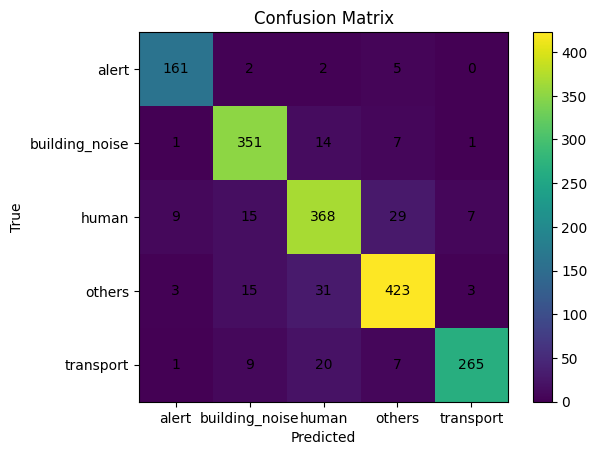

In [17]:
# 11. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

labels = np.unique(y)
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [11]:
# =========================
# 10. Predict custom
# =========================
# ======================
# 🧠 КЛАССЫ
# ======================
CLASS_NAMES = {
    0: "transport",
    1: "human",
    2: "alert",
    3: "building_noise"
}

# ======================
# 🎧 FEATURE EXTRACTION
# ======================
def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE)

        if len(y) < SAMPLES:
            y = np.pad(y, (0, SAMPLES - len(y)))
        else:
            y = y[:SAMPLES]

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=N_MELS
        )

        mel_db = librosa.power_to_db(mel, ref=np.max)

        if mel_db.shape[1] < MAX_LEN:
            mel_db = np.pad(mel_db, ((0,0),(0,MAX_LEN - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :MAX_LEN]

        mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)

        return mel_db

    except Exception as e:
        print(f"Error with file {file_path}: {e}")
        return None

# ======================
# 🔮 PREDICT
# ======================
def predict_audio_class(file_path):
    features = extract_features(file_path)

    if features is None:
        return None

    features = features[np.newaxis, ..., np.newaxis]

    preds = model.predict(features)
    class_id = np.argmax(preds)
    confidence = float(np.max(preds))

    return CLASS_NAMES[class_id], confidence

user_audio_folder = "UrbanSound8K/Test/user_audio/"

for file_name in os.listdir(user_audio_folder):
    if file_name.endswith(".wav"):
        file_path = os.path.join(user_audio_folder, file_name)

        result = predict_audio_class(file_path)

        if result:
            label, conf = result
            print(f"{file_name} → {label} ({conf:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
auto-volkswagen-engine-at-low-speed-entry-outside.wav → transport (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
distant-calm-measured-sound-of-a-running-car-engine.wav → transport (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
engine-start-and-sound.wav → human (0.66)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Recording (11).wav → human (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Recording (12).wav → human (0.88)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Recording (13).wav → human (0.98)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Recording (14).wav → human (0.60)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Recording (15).wav → human (0.99)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Recording (16).wav → human (0.98)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Recording (17).wav → human (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Recording (18).wav → human (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Recording (19).wav → human (0.99)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Recording

In [13]:
import matplotlib.pyplot as plt
import librosa.display

def show_spectrogram(file_path):
    y, sr = librosa.load(file_path, sr=16000)

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        mel_db,
        sr=sr,
        x_axis='time',
        y_axis='mel'
    )

    plt.colorbar(format='%+2.0f dB')
    plt.title("Mel-Spectrogram")
    plt.tight_layout()
    plt.show()

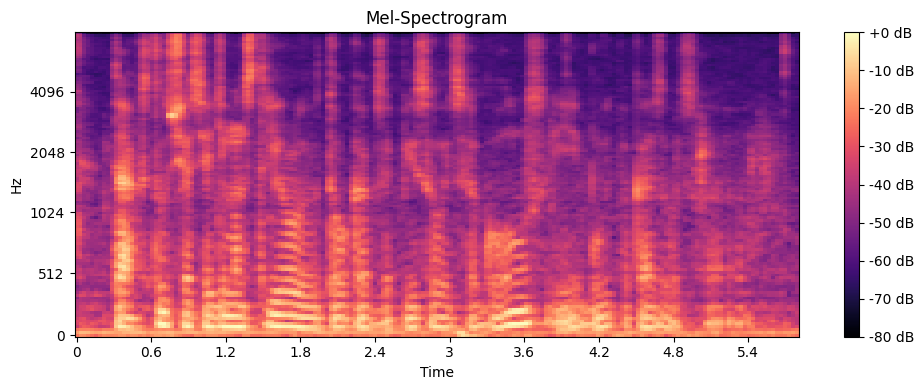

In [15]:
show_spectrogram("UrbanSound8K/Test/user_audio/Recording (11).wav")